In [7]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 

from lifelines import KaplanMeierFitter

In [3]:
cancer_data = pd.read_csv(r"C:\Users\Dell\Desktop\PancreaticCancer\pancreatic_cancer_dataset_cleaned.csv")

In [4]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            2000 non-null   object 
 1   Diagnosis_Year        2000 non-null   int64  
 2   Diagnosis_Date        2000 non-null   object 
 3   WHO_Region            2000 non-null   object 
 4   Country               2000 non-null   object 
 5   Age                   2000 non-null   int64  
 6   Gender                2000 non-null   object 
 7   Ethnicity             2000 non-null   object 
 8   Smoking_Status        2000 non-null   object 
 9   Pack_Years            2000 non-null   int64  
 10  Alcohol_Use           2000 non-null   object 
 11  BMI                   2000 non-null   float64
 12  BMI_Category          2000 non-null   object 
 13  Diabetes_Status       2000 non-null   object 
 14  Chronic_Pancreatitis  2000 non-null   object 
 15  Family_History       

In [16]:
bins = [0, 20, 30, 40, 50, 60, 70, float("inf")]  
labels = ["0-19", "20-29","30-39", "40-49", "50-59", "60-69", "70+"]

cancer_data["Age_Group"] = pd.cut(cancer_data["Age"], bins=bins, labels=labels, right=False)

print(cancer_data["Age_Group"].value_counts().sort_index())

Age_Group
0-19       0
20-29      0
30-39      8
40-49     64
50-59    384
60-69    813
70+      731
Name: count, dtype: int64


In [27]:
time = cancer_data["Survival_Months"]
event = cancer_data["Survived"]

##  Overall Kaplan-Meier (all patients)

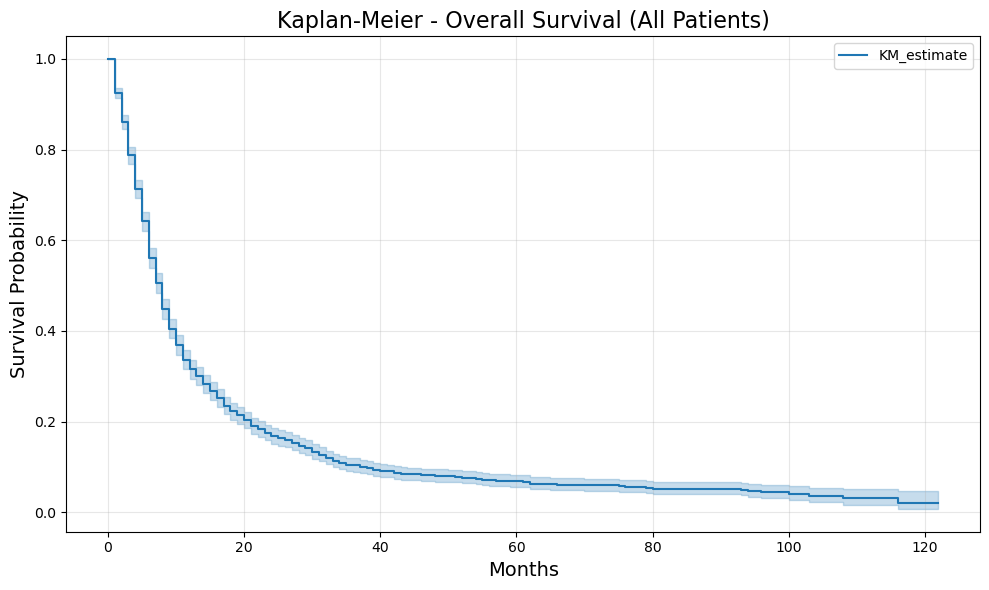

Median survival time: 8.0 months
95% confidence interval:        KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.0                  1.000000                1.000000
1.0                  0.912566                0.935729
2.0                  0.845391                0.875745
3.0                  0.768701                0.804650
4.0                  0.693180                0.732923
...                       ...                     ...
108.0                0.016741                0.050409
112.0                0.016741                0.050409
116.0                0.006720                0.047741
117.0                0.006720                0.047741
122.0                0.006720                0.047741

[97 rows x 2 columns]


In [36]:
kmf = KaplanMeierFitter()
kmf.fit(time, event_observed=event)

# Plot
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier - Overall Survival (All Patients)", fontsize=16)
plt.xlabel("Months", fontsize=14)
plt.ylabel("Survival Probability", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistics
print(f"Median survival time: {kmf.median_survival_time_:.1f} months")
print(f"95% confidence interval: {kmf.confidence_interval_}")